In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [2]:
df = pd.read_csv("twitter_training.csv", header=None)

In [3]:
df.columns = ["ID", "Entity", "Sentiment", "Tweet"]

In [4]:
df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
df.shape

(74682, 4)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [7]:
df.describe(include="all")

,ID,Entity,Sentiment,Tweet
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,Microsoft,Negative,
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


In [8]:
df.isnull().sum()

ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

ID           0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

In [11]:
df["Sentiment"].value_counts()

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

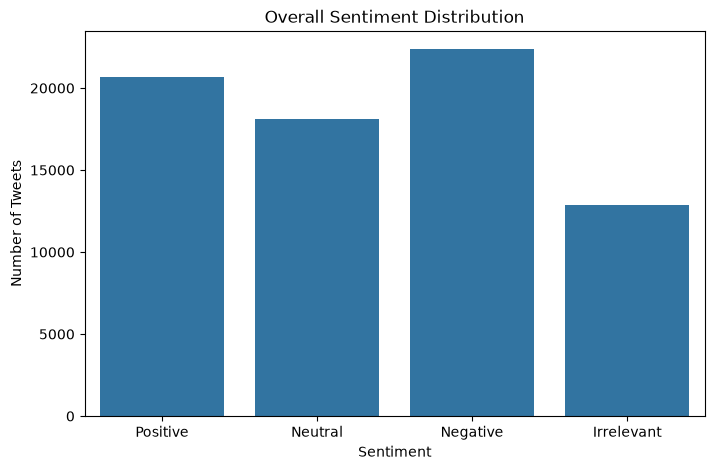

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [13]:
df["Entity"].value_counts().head(10)

Entity
LeagueOfLegends         2377
MaddenNFL               2377
CallOfDuty              2376
Verizon                 2365
TomClancysRainbowSix    2364
Facebook                2362
Microsoft               2361
Dota2                   2359
WorldOfCraft            2357
ApexLegends             2353
Name: count, dtype: int64

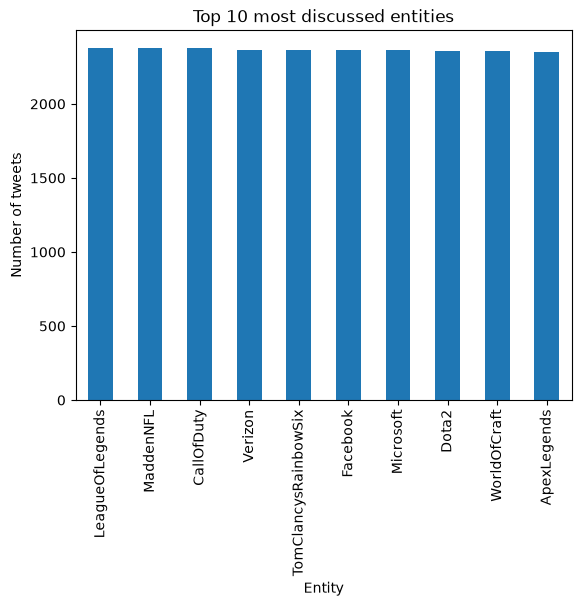

In [15]:
df["Entity"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 most discussed entities")
plt.xlabel("Entity")
plt.ylabel("Number of tweets")
plt.savefig("Top 10 most discussed entities",dpi=300) 

plt.show()

In [16]:
pd.crosstab(df["Entity"],df["Sentiment"]).head(10)

Sentiment,Irrelevant,Negative,Neutral,Positive
Entity,,,,
Amazon,186,575,1207,308
ApexLegends,192,591,936,634
AssassinsCreed,264,375,156,1439
Battlefield,915,464,351,586
Borderlands,240,426,597,1017
CS-GO,632,344,548,760
CallOfDuty,672,883,375,446
CallOfDutyBlackopsColdWar,569,566,352,856
Cyberpunk2077,465,385,462,950


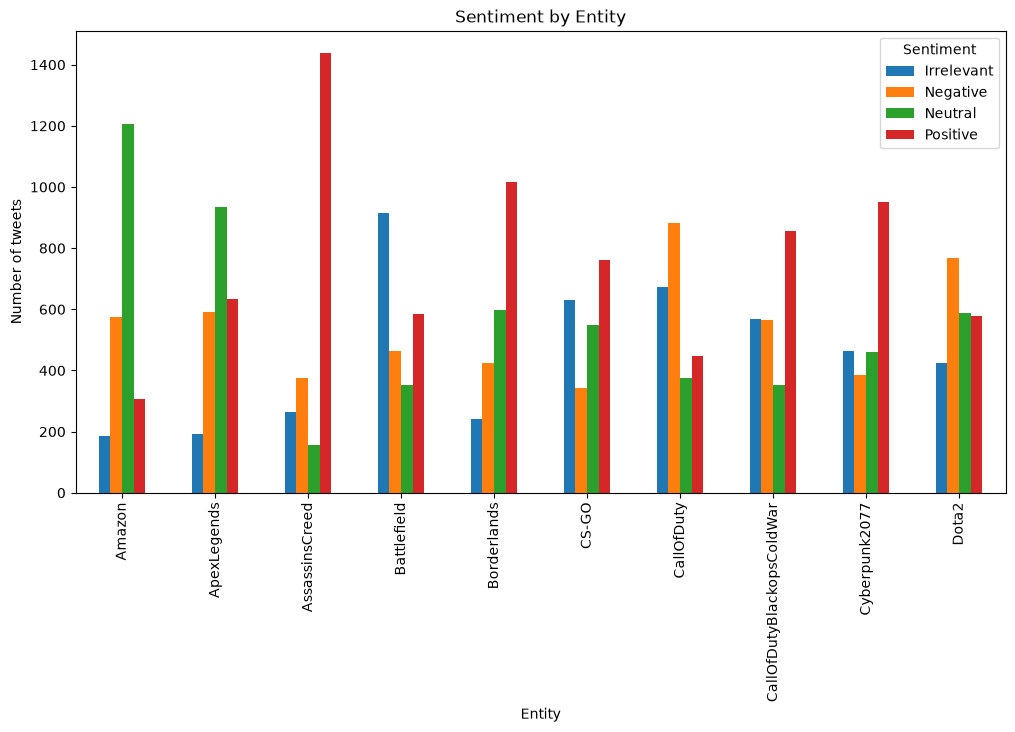

In [17]:
pd.crosstab(df["Entity"],df["Sentiment"]).head(10).plot(kind="bar",figsize=(12,6))
plt.title("Sentiment by Entity")
plt.xlabel("Entity")
plt.ylabel("Number of tweets")
plt.savefig("Sentiment by Entity",dpi=300) 

plt.show()

ValueError: incomplete format

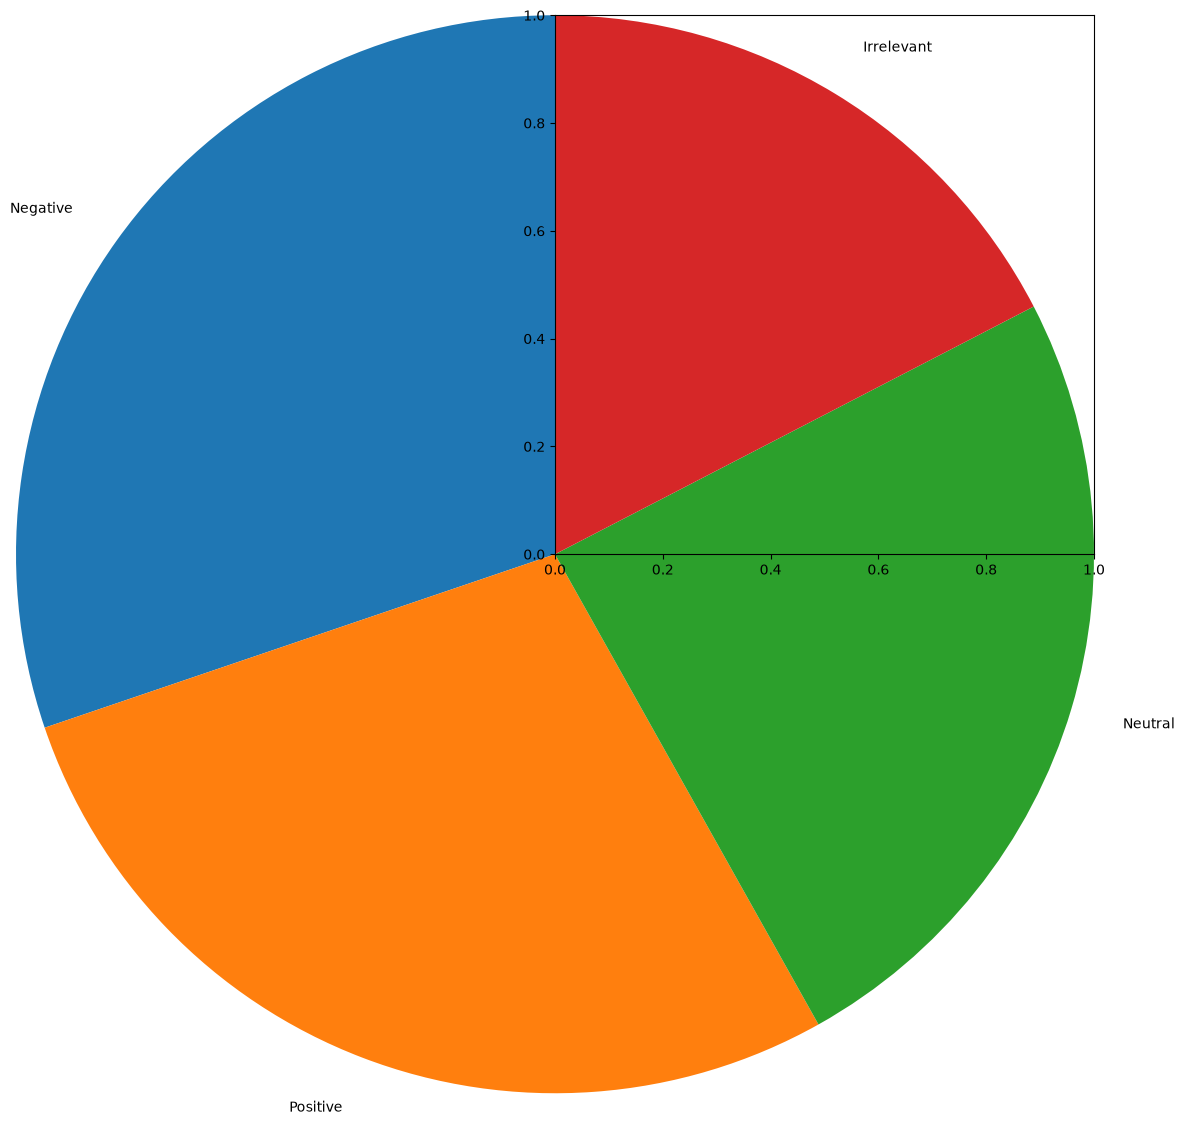

In [21]:
sentiment=df["Sentiment"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(sentiment.values,labels=sentiment.index,autopct="%1.1f%",startangle=90)

plt.title("Sentiment Percentage")
plt.savefig("Sentiment percentage.png",dpi=300)
plt.show()

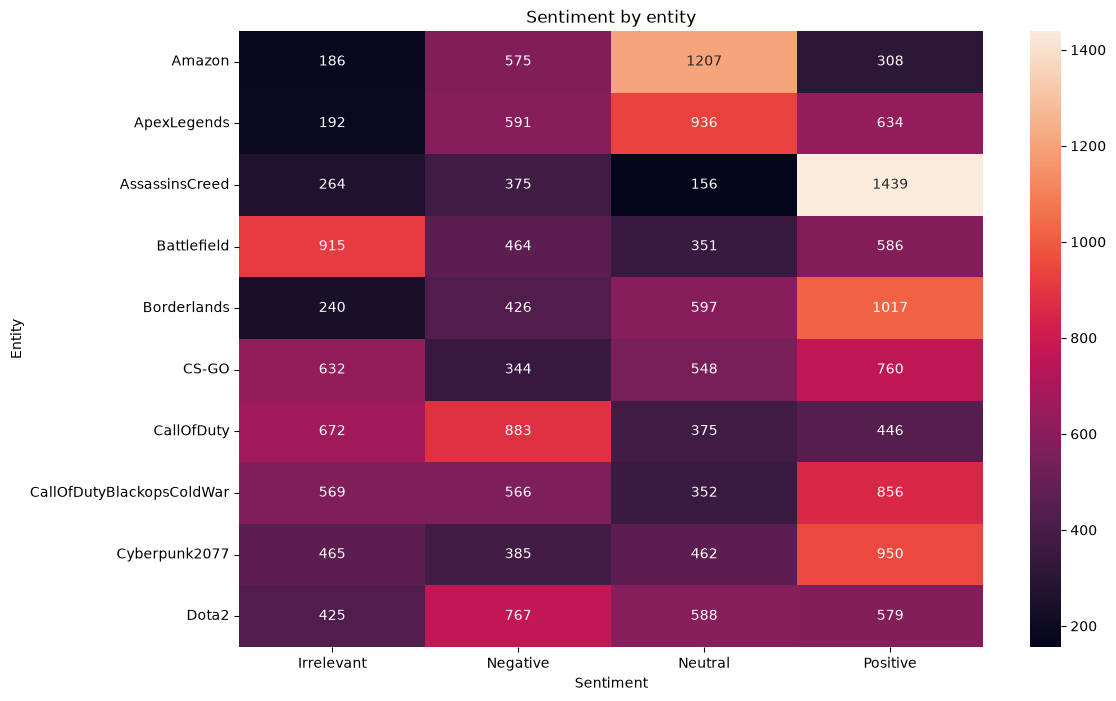

In [20]:
sentiment_entity =pd.crosstab(df["Entity"],df["Sentiment"])
plt.figure(figsize=(12,8))
sns.heatmap(sentiment_entity.head(10),annot=True,fmt="d")
plt.title("Sentiment by entity")
plt.xlabel("Sentiment")
plt.ylabel("Entity")
plt.savefig("Sentiment  by entity.png",dpi=300)
plt.show()